# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
quantidade = 1000
up = 621
down = 379

up_array = np.random.normal(2, 1.5, up)
down_array = np.random.normal(-2, 1.5, down)

up_down = np.concat([up_array, down_array])
up_down.shape

(1000,)

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [62]:
up_down_pacientes = np.random.randint(-10, 7,1000)
up_down_pacientes.shape

(1000,)

In [63]:
pacientes = [f"paciente_{i}" for i in range(1, 1001)]

In [64]:
df = pd.DataFrame({
    'Expressão': up_down,
    'Diferencial': up_down_pacientes,
    'Pacientes': pacientes  
})
df

,Expressão,Diferencial,Pacientes
0,2.595226,0,paciente_1
1,-0.477722,-5,paciente_2
2,2.074835,1,paciente_3
3,2.478593,0,paciente_4
4,3.152153,-10,paciente_5
...,...,...,...
995,-2.196680,-7,paciente_996
996,-0.602008,-9,paciente_997
997,-2.242457,3,paciente_998
998,-1.698975,0,paciente_999


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Para o tipo de dado criado sendo interpretado como se fosse um unico gene testado em 1000 pacientes a classificação possível que imaginei foi distinguir eles por clasificação da expressão

In [65]:
bins = [-np.inf, -4, -1, 0, 1, 4, np.inf]

labels = [
    'Muito downregulated',
    'Downregulated',
    'Levemente down',
    'Neutro',
    'Levemente up',
    'Muito upregulated'
]

df['Grupo'] = pd.cut(df['Expressão'], bins=bins, labels=labels)
df.head()

,Expressão,Diferencial,Pacientes,Grupo
0,2.595226,0,paciente_1,Levemente up
1,-0.477722,-5,paciente_2,Levemente down
2,2.074835,1,paciente_3,Levemente up
3,2.478593,0,paciente_4,Levemente up
4,3.152153,-10,paciente_5,Levemente up


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [66]:
def tabela_frequencia(serie):
    freq_abs = serie.value_counts().sort_index()
    freq_rel = serie.value_counts(normalize=True).sort_index()

    df_freq = pd.DataFrame({
        'Frequencia_Absoluta': freq_abs,
        'Frequencia_Relativa': freq_rel
    })
    
    return df_freq

In [67]:
freq_expressao = tabela_frequencia(df['Grupo'])
freq_expressao

,Frequencia_Absoluta,Frequencia_Relativa
Grupo,,
Muito downregulated,40,0.040
Downregulated,257,0.257
Levemente down,107,0.107
Neutro,121,0.121
Levemente up,408,0.408
Muito upregulated,67,0.067


In [68]:
freq_genes = tabela_frequencia(df['Diferencial'])
freq_genes

,Frequencia_Absoluta,Frequencia_Relativa
Diferencial,,
-10,72,0.072
-9,66,0.066
-8,65,0.065
-7,58,0.058
-6,50,0.050
-5,59,0.059
-4,50,0.050
-3,57,0.057
-2,54,0.054


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

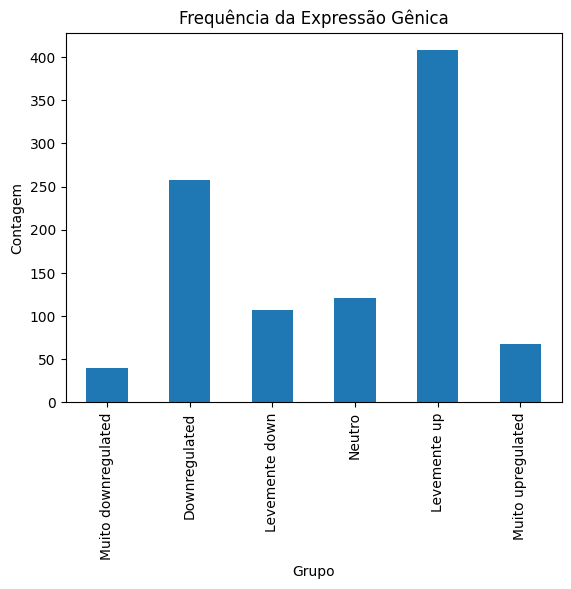

In [69]:
freq_expressao['Frequencia_Absoluta'].plot(kind='bar')
plt.title('Frequência da Expressão Gênica')
plt.ylabel('Contagem')
plt.show()

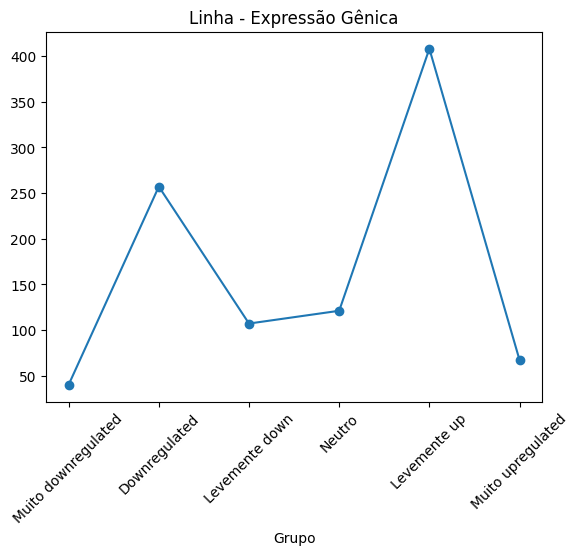

In [70]:
freq_expressao['Frequencia_Absoluta'].plot(kind='line', marker='o')
plt.title('Linha - Expressão Gênica')
plt.xticks(rotation=45)
plt.show()

### Número

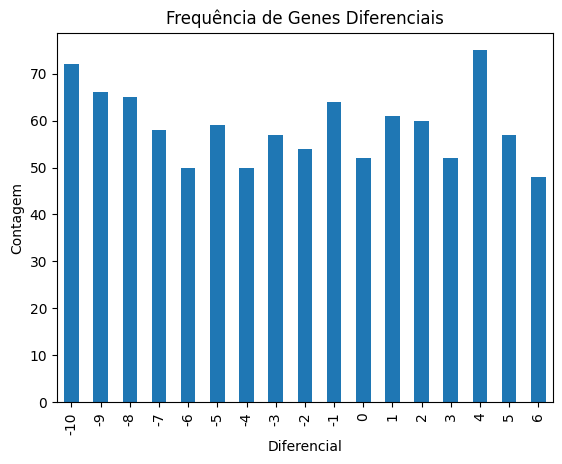

In [71]:
freq_genes['Frequencia_Absoluta'].plot(kind='bar')
plt.title('Frequência de Genes Diferenciais')
plt.ylabel('Contagem')
plt.show()

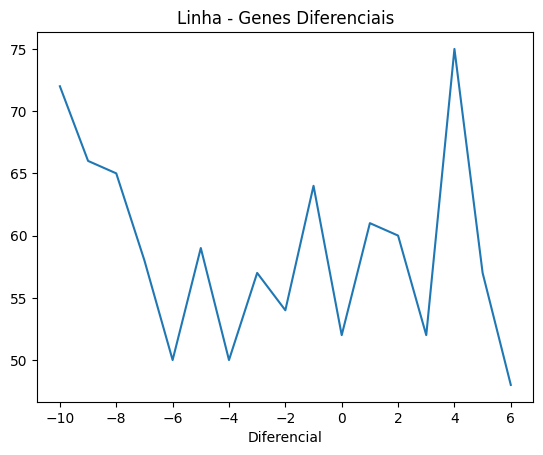

In [72]:
freq_genes['Frequencia_Absoluta'].plot(kind='line')
plt.title('Linha - Genes Diferenciais')
plt.show()

## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

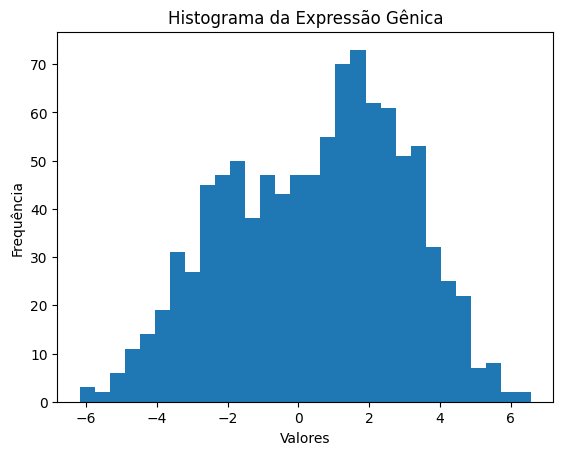

In [73]:
plt.hist(df['Expressão'], bins=30)
plt.title('Histograma da Expressão Gênica')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

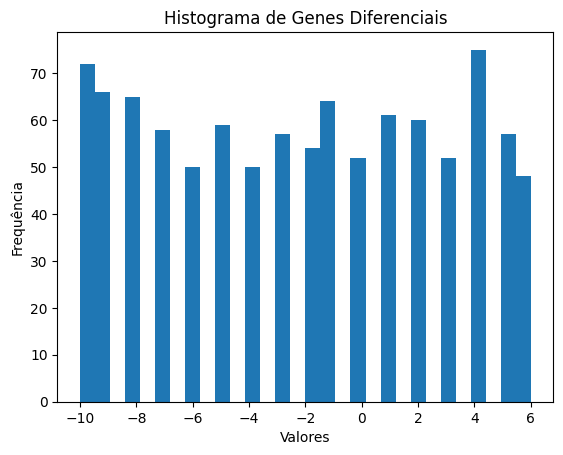

In [74]:
plt.hist(df['Diferencial'], bins=30)
plt.title('Histograma de Genes Diferenciais')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

##Que histograma horroroso

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

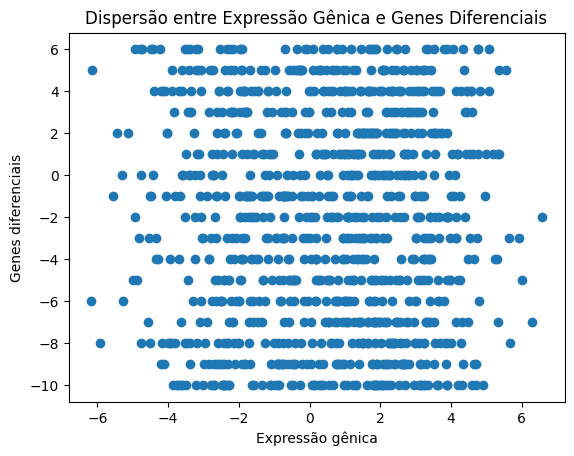

In [75]:
plt.scatter(df['Expressão'], df['Diferencial'])

plt.title('Dispersão entre Expressão Gênica e Genes Diferenciais')
plt.xlabel('Expressão gênica')
plt.ylabel('Genes diferenciais')
plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

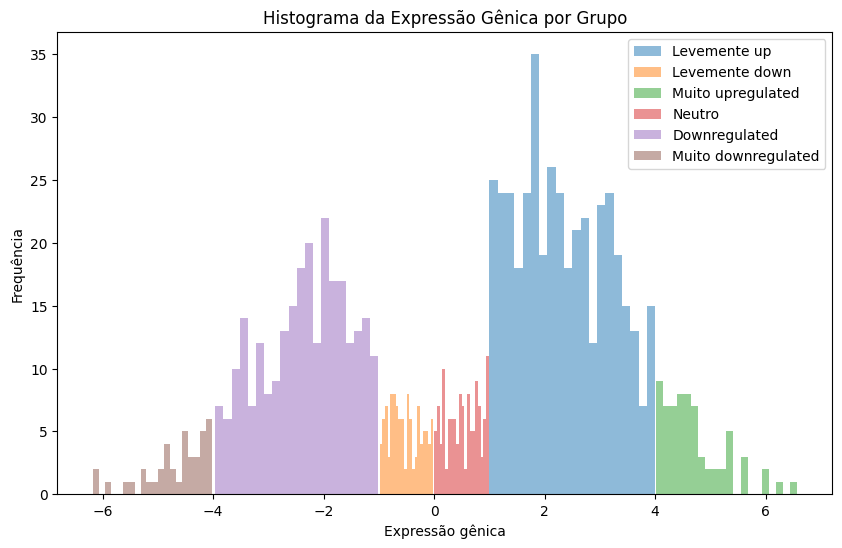

In [78]:
plt.figure(figsize=(10, 6))

for grupo in df['Grupo'].unique():
    dados = df[df['Grupo'] == grupo]['Expressão']
    plt.hist(dados, bins=20, alpha=0.5, label=grupo)

plt.title('Histograma da Expressão Gênica por Grupo')
plt.xlabel('Expressão gênica')
plt.ylabel('Frequência')
plt.legend()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

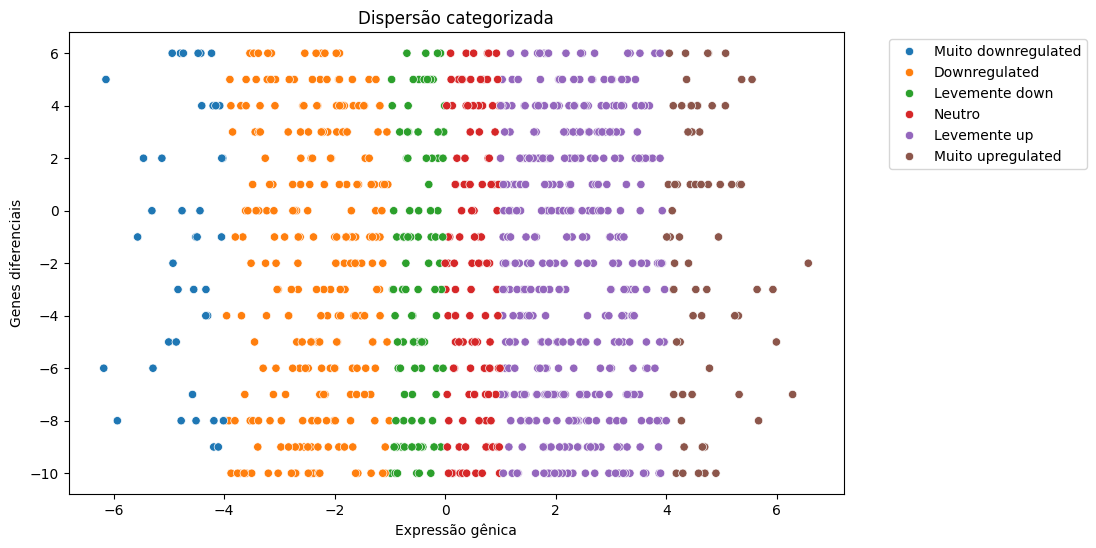

In [80]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Expressão',
    y='Diferencial',
    hue='Grupo'
)

plt.title('Dispersão categorizada')
plt.xlabel('Expressão gênica')
plt.ylabel('Genes diferenciais')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|| 
| % de células positivas||
| Faixa de pH||
| Valor de pH||
| mol/L||
| UFC||
| D.O.|| Continua |
| Grupo Sanguíneo||
| Sorologia||

1- Discreta
<br>2- Continua
<br>3- Ordinal
<br>4- Continua
<br>5- Continua
<br>6- Discreta
<br>7- Continua
<br>8- Nominal
<br>9- Nominal